In [232]:
#1. Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/karun/OneDrive/Desktop/Machine learning/ML Assignment/kidney_dataset.csv")

print(df.shape)
print(df.head())

(5000, 11)
   Creatinine        BUN         GFR  Urine_Output  Diabetes  Hypertension  \
0    0.788803   8.386869  102.161787   1632.649387         0             0   
1    3.413970  53.688796   50.071257    935.540516         1             0   
2    0.647645   7.466540   89.451831   1774.553846         1             1   
3    0.795508  12.516821   99.872180   2360.602980         0             0   
4    0.869010  19.855960   86.110182   1987.750901         0             1   

         Age  Protein_in_Urine  Water_Intake     Medication  CKD_Status  
0  27.682074        106.700203      1.570370            NaN           0  
1  33.122208        410.008362      3.425287  ACE Inhibitor           1  
2  55.832284        123.336925      1.123301       Diuretic           0  
3  32.391900        116.098870      3.086846  ACE Inhibitor           0  
4  66.689515         55.668760      2.174980            ARB           0  


In [233]:
#2. Check Missing Values
print(df.isnull().sum())

Creatinine             0
BUN                    0
GFR                    0
Urine_Output           0
Diabetes               0
Hypertension           0
Age                    0
Protein_in_Urine       0
Water_Intake           0
Medication          2987
CKD_Status             0
dtype: int64


In [234]:
#3. Select Features
X = df.drop("CKD_Status", axis=1)

In [235]:
#4. Convert Categorical Column
X = pd.get_dummies(X, columns=["Medication"], drop_first=True)

print(X.head())
print(X.shape)

   Creatinine        BUN         GFR  Urine_Output  Diabetes  Hypertension  \
0    0.788803   8.386869  102.161787   1632.649387         0             0   
1    3.413970  53.688796   50.071257    935.540516         1             0   
2    0.647645   7.466540   89.451831   1774.553846         1             1   
3    0.795508  12.516821   99.872180   2360.602980         0             0   
4    0.869010  19.855960   86.110182   1987.750901         0             1   

         Age  Protein_in_Urine  Water_Intake  Medication_ARB  \
0  27.682074        106.700203      1.570370           False   
1  33.122208        410.008362      3.425287           False   
2  55.832284        123.336925      1.123301           False   
3  32.391900        116.098870      3.086846           False   
4  66.689515         55.668760      2.174980            True   

   Medication_Diuretic  
0                False  
1                False  
2                 True  
3                False  
4                Fals

In [236]:
#5. Handle Missing Values
X = X.fillna(X.median(numeric_only=True))

In [237]:
X = X.fillna(0)

In [238]:
#6. Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(5000, 11)


In [239]:
#7. K-MEANS
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print(clusters)

[0 1 2 ... 0 0 0]


In [240]:
df["KMeans_Cluster"] = clusters

print(df[["KMeans_Cluster"]].head())

   KMeans_Cluster
0               0
1               1
2               2
3               0
4               0


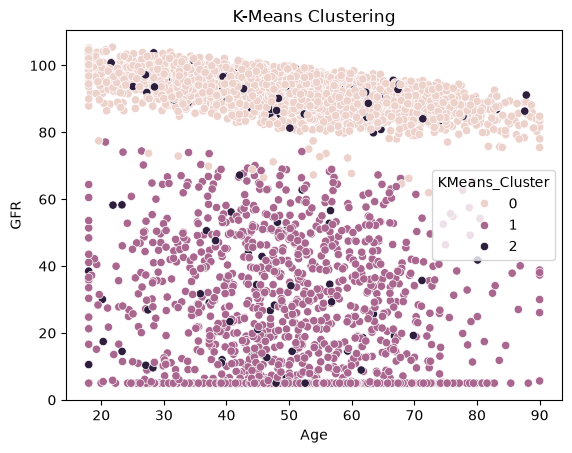

In [241]:
#8. Visualize K-Means
sns.scatterplot(
    data=df,
    x="Age",
    y="GFR",
    hue="KMeans_Cluster"
)

plt.title("K-Means Clustering")
plt.show()

In [242]:
#9. Find Best K — Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

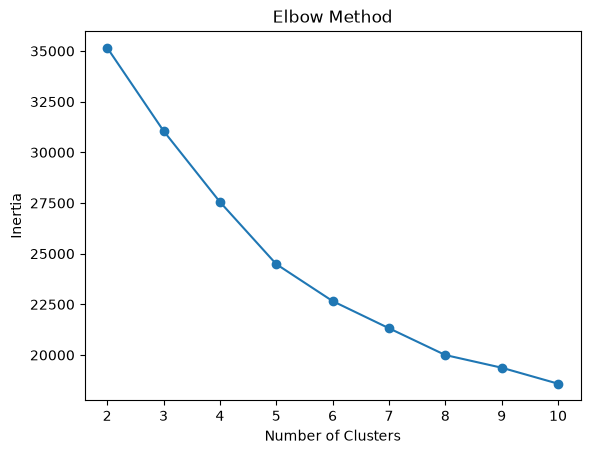

In [243]:
plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [244]:
#10. Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3
)

clusters_h = hierarchical.fit_predict(X_scaled)

print(clusters_h)

[0 1 2 ... 0 0 0]


In [245]:
df["Hierarchical_Cluster"] = clusters_h

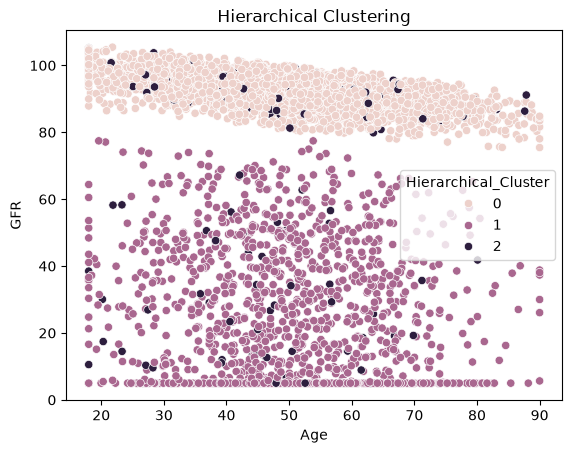

In [246]:
sns.scatterplot(
    data=df,
    x="Age",
    y="GFR",
    hue="Hierarchical_Cluster"
)

plt.title("Hierarchical Clustering")
plt.show()

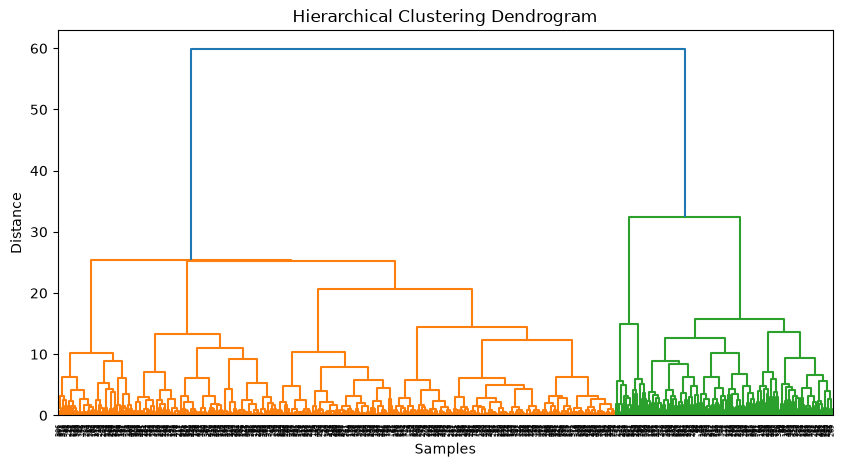

In [247]:
#11. Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

sample = X_scaled[:500]

linked = linkage(
    sample,
    method="ward"
)

plt.figure(figsize=(10, 5))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

In [248]:
#12SVD — Singular Value Decomposition
import numpy as np

# SVD
U, S, VT = np.linalg.svd(X_scaled)

print("U shape:", U.shape)
print("S shape:", S.shape)
print("VT shape:", VT.shape)

U shape: (5000, 5000)
S shape: (11,)
VT shape: (11, 11)


In [249]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_svd = svd.fit_transform(X_scaled)

print("SVD result shape:", X_svd.shape)
print(X_svd[:5])

SVD result shape: (5000, 2)
[[ 1.22806434  0.02832064]
 [-1.41912767  0.56335859]
 [ 1.06116522  3.22007794]
 [ 1.68308724  0.40360292]
 [ 1.06538204 -1.88364891]]


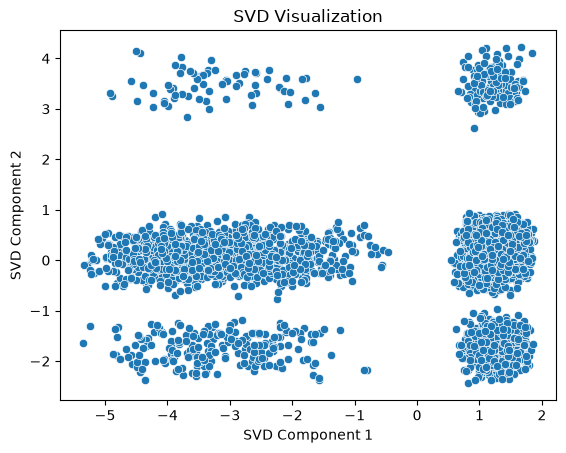

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x=X_svd[:, 0],
    y=X_svd[:, 1]
)

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("SVD Visualization")

plt.show()

In [251]:
#13SOM — Self-Organizing Maps
#pip install minisom
from minisom import MiniSom
import numpy as np

# Create SOM
som = MiniSom(
    x=5,
    y=5,
    input_len=X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

# Initialize weights
som.random_weights_init(X_scaled)

# Train SOM
som.train_random(
    X_scaled,
    1000
)

print("SOM training completed")

SOM training completed


In [252]:
som_clusters = []

for sample in X_scaled:
    winner = som.winner(sample)
    som_clusters.append(winner)

print(som_clusters[:10])

[(np.int64(3), np.int64(3)), (np.int64(2), np.int64(1)), (np.int64(4), np.int64(4)), (np.int64(4), np.int64(2)), (np.int64(0), np.int64(3)), (np.int64(0), np.int64(3)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(2)), (np.int64(2), np.int64(4))]


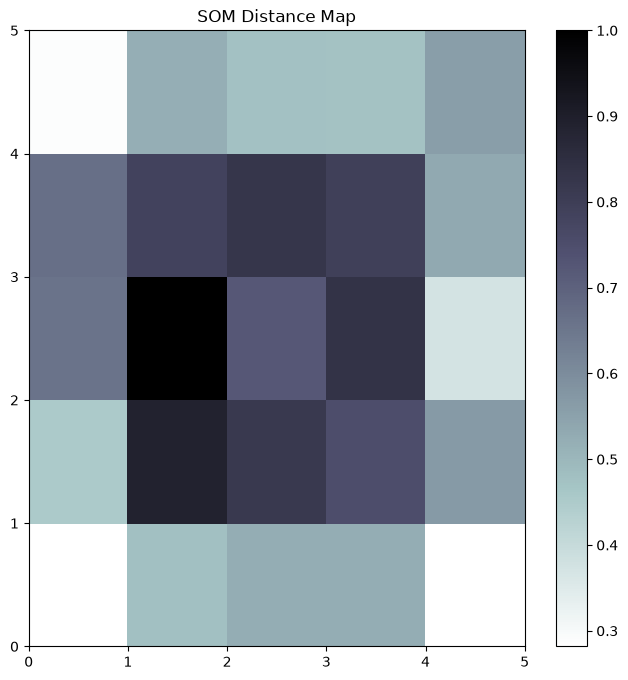

In [253]:
plt.figure(figsize=(8, 8))

plt.pcolor(
    som.distance_map().T,
    cmap="bone_r"
)

plt.colorbar()

plt.title("SOM Distance Map")
plt.show()